We compare the **PMP** and the **gradient descent** algorithms.
The function that has to be approximated is
$$f(x) = \frac{1}{1 + \frac 1 d \sum_{i=1} x_i}$$

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

# Setting

In [2]:
from ctt.bases import make_canonical_polynomials

d = 5
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
bases = [basis]*(d+1)
key = random.PRNGKey(42)

In [3]:
@jax.jit
def target(x: Float[Array, "d"]) -> float:
    return 1./(1. + jnp.mean(x))

In [5]:
from ctt.tt import TT, tt_matvec

def _ftt(x: Float[Array, "d"], tt: TT) -> Float[Array, "d"]:
    features = [bases[i](x[i]) for i in range(x.shape[0])]  # (m,)*d
    result = tt_matvec(tt, features)  # (d, 1)
    return result[:, 0]

@jax.jit
def ctt(tts: list[TT], x: Float[Array, "d"]) -> Float[Array, "d"]:

    def _body_fn(i: int, val: Float[Array, "d"]) -> Float[Array, "d"]:
        control = jax.lax.switch(i, [lambda u=u: u for u in tts])
        return val + _ftt(val, control)
    
    result = jax.lax.fori_loop(0, len(tts), _body_fn, x)
    return result

In [67]:
key, train_key, val_key = random.split(key, 3)

N_train = 3000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=0., maxval=1.)
y_train = jax.vmap(target)(X_train)
X_train = jnp.concatenate((jnp.ones((N_train, 1)), X_train), axis=1)
y_train = jnp.concatenate((y_train[:, None], X_train[:, 1:]), axis=1)

N_val = 1000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=0., maxval=1.)
y_val = jax.vmap(target)(X_val)
X_val = jnp.concatenate((jnp.ones((N_val, 1)), X_val), axis=1)
y_val = jnp.concatenate((y_val[:, None], X_val[:, 1:]), axis=1)

num_steps = 8
regularization_coeff = 1e-4
radius = None
ranks = [d + 1] + [2] * (d) + [1]

# Gradient descent

In [68]:
import optax
from ctt.tt import tt_norm, TT

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d"],
                 alpha: float = 0.) -> tuple[float,float]:
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    penalty = alpha*jnp.sum(jnp.asarray([tt_norm(u)**2 for u in tts]))
    return loss + penalty, loss

In [69]:
def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d"]],
                     val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d"]],
                     optimizer: optax.GradientTransformation,
                     params: list[TT],
                     opt_steps: int,
                     regularization_coeff: float,
                     batch_size: int = 64) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    @jax.jit
    def step(tts: list[TT],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"],
             alpha: float = 0.):
        (loss, l2_error), grads = jax.value_and_grad(compute_loss, has_aux=True)(tts, x, y, alpha)
        updates, opt_state = optimizer.update(grads, opt_state, tts)
        params = optax.apply_updates(tts, updates)
        return params, opt_state, l2_error

    for i in range(opt_steps):
        start_idx = i*batch_size % N_train
        stop_idx = (i+1)*batch_size % N_train
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            X_train[start_idx:stop_idx], 
                                            y_train[start_idx:stop_idx], 
                                            alpha=regularization_coeff)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses)

# PMP

In [70]:
from typing import Optional
from ctt.tt import tt_mul_scalar, tt_add, tt_retract

def regularization(
    xk: Float[Array, "B d"], control: TT, coefficient: float
) -> float:
    return coefficient * tt_norm(control) ** 2


def terminal_cost(xT: Float[Array, "B d"], y: Float[Array, "B d"]) -> float:
    return jnp.mean(optax.l2_loss(xT, y))


def transition(xk: Float[Array, "B d"], control: TT) -> Float[Array, "B d"]:
    psi = jax.vmap(_ftt, in_axes=(0, None))(xk, control)
    return xk + psi


def _compute_B(
    features: list[Float[Array, "B m"]], costates: Float[Array, "B d"], ranks: list[int]
) -> TT:
    assert len(ranks) == len(features) + 1
    d = len(features)
    # compute the first component by multiplying the first factor by the costates `lambda`
    first_comp = jnp.einsum("bd,bm->dmb", costates, features[0])  # (d, m, B)

    def _factor_to_core(factor: Float[Array, "r n"]) -> Float[Array, "r n r"]:
        r, n = factor.shape
        return jax.vmap(jnp.diag, in_axes=1)(factor).transpose(2, 0, 1)

    # converting the factors to TT cores and projecting back to the TT manifold
    tt_cores = [None] * d
    tt_cores[0] = first_comp
    for mu in range(d - 1):
        core = tt_cores[mu]
        r1, m, r2 = core.shape

        # compute the SVD of the current core
        u, s, vh = jnp.linalg.svd(core.reshape(r1 * m, r2), full_matrices=False)
        new_rank = ranks[mu + 1]
        # truncate the SVD to project back to the TT manifold
        u, s, vh = u[:, :new_rank], s[:new_rank], vh[:new_rank, :]

        # replace the TT core
        tt_cores[mu] = u.reshape((r1, m, new_rank))
        # update the next core
        if mu == d - 2:
            next_core = features[-1][..., None]
        else:
            next_core = _factor_to_core(features[mu + 1])
        tt_cores[mu + 1] = jnp.einsum("ir,rkl->ikl", s[:, None] * vh, next_core)

    return tt_cores


def min_hamiltonian(
    states: Float[Array, "B d"],
    costates: Float[Array, "B d"],
    control: TT,
    coefficient: float,
    ranks: list[int],
    radius: Optional[float] = None,
    learning_rate: Optional[float] = None
) -> TT:
    B, d = states.shape
    features = [
        jax.vmap(bases[i])(states[:, i]) for i in range(states.shape[1])
    ]  # (B, m)*d
    tt = _compute_B(features, costates, ranks)
    tt = tt_mul_scalar(tt, -1.0 / coefficient)
    if learning_rate:
        tt = tt_add(tt_mul_scalar(control, 1.0 - learning_rate), tt_mul_scalar(tt, learning_rate))
        tt = tt_retract(tt, ranks)

    if radius:
        # project the TT to the closed ball of radius `radius`
        norm = tt_norm(tt)
        tt = jax.lax.cond(
            norm <= radius, lambda u: u, lambda u: tt_mul_scalar(u, radius / norm), tt
        )

    return tt

In [71]:
from ctt.optimizer import batch_pmp

def pmp(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d"]],
        val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d"]],
        params: list[TT],
        opt_steps: int,
        regularization_coeff: float,
        radius: Optional[float] = None,
        learning_rate: Optional[float] = None) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset

    optimizer = batch_pmp(regularization=jax.tree_util.Partial(regularization, coefficient=regularization_coeff),
                          terminal_cost=jax.tree_util.Partial(terminal_cost, y=y_train),
                          transition=transition,
                          min_hamiltonian=jax.tree_util.Partial(min_hamiltonian,
                                                                coefficient=regularization_coeff,
                                                                ranks=ranks,
                                                                radius=radius,
                                                                learning_rate=learning_rate),
                          x0=X_train,
                          num_steps=num_steps)
    optimizer = jax.jit(optimizer)

    train_losses = []
    val_losses = []
    for i in range(opt_steps):
        params = optimizer(params)
        
        _, train_loss = compute_loss(params, X_train, y_train, alpha=0.)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Iter {i} | Train loss: {train_loss:.3e} | Val loss: {val_loss:.3e}")
    
    return params, (train_losses, val_losses)

# Comparison

In [72]:
from ctt.tt import tt_zeros, tt_randn

control_keys = random.split(key, num_steps)

init_controls = [
    tt_randn(control_key, [n_features] * (d + 1), ranks, cov=1.0)
    for control_key in control_keys
    # tt_zeros([n_features] * (d + 1), ranks)
    # for _ in range(num_steps)
]
print(list(map(tt_norm, init_controls)))

[Array(0.00069692, dtype=float64), Array(0.00022551, dtype=float64), Array(6.22689336e-05, dtype=float64), Array(0.00012944, dtype=float64), Array(9.7337161e-05, dtype=float64), Array(0.00069788, dtype=float64), Array(8.02006665e-05, dtype=float64), Array(0.00020232, dtype=float64)]


In [73]:
optimizer = optax.adam(learning_rate=5e-3)
params_gd, (train_losses_gd, val_losses_gd) = gradient_descent(train_dataset=(X_train, y_train),
                                                               val_dataset=(X_val, y_val),
                                                               optimizer=optimizer,
                                                               params=init_controls,
                                                               opt_steps=2000,
                                                               regularization_coeff=regularization_coeff,
                                                               batch_size=64)

Iter 0 | Loss: 9.212e-03 | Val loss: 9.258e-03
Iter 5 | Loss: 9.776e-03 | Val loss: 9.210e-03
Iter 10 | Loss: 9.253e-03 | Val loss: 9.017e-03
Iter 15 | Loss: 8.434e-03 | Val loss: 8.396e-03
Iter 20 | Loss: 7.918e-03 | Val loss: 6.754e-03
Iter 25 | Loss: 4.052e-03 | Val loss: 3.355e-03
Iter 30 | Loss: 7.720e-04 | Val loss: 8.475e-04
Iter 35 | Loss: 1.829e-03 | Val loss: 1.456e-03
Iter 40 | Loss: 5.467e-04 | Val loss: 6.058e-04
Iter 45 | Loss: 7.723e-04 | Val loss: 8.182e-04
Iter 50 | Loss: 6.472e-04 | Val loss: 5.375e-04
Iter 55 | Loss: 4.447e-04 | Val loss: 3.061e-04
Iter 60 | Loss: 3.204e-04 | Val loss: 3.484e-04
Iter 65 | Loss: 2.005e-04 | Val loss: 2.191e-04
Iter 70 | Loss: 1.641e-04 | Val loss: 1.931e-04
Iter 75 | Loss: 1.831e-04 | Val loss: 1.540e-04
Iter 80 | Loss: 9.244e-05 | Val loss: 1.244e-04
Iter 85 | Loss: 1.289e-04 | Val loss: 9.773e-05
Iter 90 | Loss: 8.148e-05 | Val loss: 7.945e-05
Iter 95 | Loss: 6.080e-05 | Val loss: 6.359e-05
Iter 100 | Loss: 4.901e-05 | Val loss: 5.0

In [81]:
params_pmp, (train_losses_pmp, val_losses_pmp) = pmp(train_dataset=(X_train, y_train),
                                                     val_dataset=(X_val, y_val),
                                                     params=init_controls,
                                                     opt_steps=1000,
                                                     regularization_coeff=regularization_coeff,
                                                     radius=1.,
                                                     learning_rate=1e-5)

Iter 0 | Train loss: 3.354e-03 | Val loss: 3.340e-03
Iter 1 | Train loss: 1.618e-03 | Val loss: 1.613e-03
Iter 2 | Train loss: 9.859e-04 | Val loss: 9.845e-04
Iter 3 | Train loss: 7.227e-04 | Val loss: 7.226e-04
Iter 4 | Train loss: 6.059e-04 | Val loss: 6.064e-04
Iter 5 | Train loss: 5.454e-04 | Val loss: 5.461e-04
Iter 6 | Train loss: 5.073e-04 | Val loss: 5.082e-04
Iter 7 | Train loss: 4.792e-04 | Val loss: 4.802e-04
Iter 8 | Train loss: 4.561e-04 | Val loss: 4.572e-04
Iter 9 | Train loss: 4.361e-04 | Val loss: 4.372e-04
Iter 10 | Train loss: 4.180e-04 | Val loss: 4.192e-04
Iter 11 | Train loss: 4.015e-04 | Val loss: 4.028e-04
Iter 12 | Train loss: 3.863e-04 | Val loss: 3.876e-04
Iter 13 | Train loss: 3.722e-04 | Val loss: 3.735e-04
Iter 14 | Train loss: 3.590e-04 | Val loss: 3.604e-04
Iter 15 | Train loss: 3.467e-04 | Val loss: 3.480e-04
Iter 16 | Train loss: 3.351e-04 | Val loss: 3.365e-04
Iter 17 | Train loss: 3.241e-04 | Val loss: 3.255e-04
Iter 18 | Train loss: 3.138e-04 | Val 

Text(0, 0.5, 'Error')

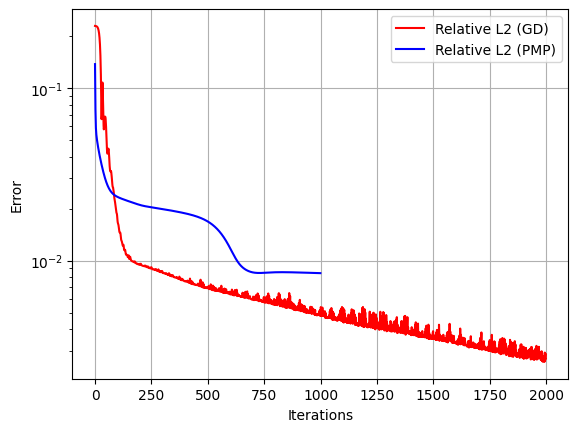

In [82]:
fig, ax = plt.subplots()

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot GD losses
val_losses_gd = jnp.asarray(val_losses_gd)

ax.semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd/y_val_norm), label="Relative L2 (GD)", color="red")
# ax.semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd), label="Absolute L2", color="red", linestyle="dashed")

# plot PMP losses
val_losses_pmp = jnp.asarray(val_losses_pmp)

ax.semilogy(jnp.arange(len(val_losses_pmp)), jnp.sqrt(val_losses_pmp/y_val_norm), label="Relative L2 (PMP)", color="blue")
# ax.semilogy(jnp.arange(len(val_losses_pmp)), jnp.sqrt(val_losses_pmp), label="Absolute L2", color="blue", linestyle="dashed")

ax.grid()
ax.legend()
ax.set_xlabel("Iterations")
ax.set_ylabel("Error")